# Hoja de Trabajo 5


## Imports

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

RNG_SEED = 42


## Task 3

### Task 3.1 — Generación de redes sintéticas y métricas comparativas

In [3]:
N = 500

# Red aleatoria Erdos-Renyi: N=500, p=0.02
G_er = nx.erdos_renyi_graph(n=N, p=0.02, seed=RNG_SEED)

# Red libre de escala Barabasi-Albert: N=500, m=5
G_ba = nx.barabasi_albert_graph(n=N, m=5, seed=RNG_SEED)

# Red de mundo pequeno Watts-Strogatz: N=500, k=6, p=0.1
G_ws = nx.watts_strogatz_graph(n=N, k=6, p=0.1, seed=RNG_SEED)

redes = {
    "Erdos-Renyi (aleatoria)": G_er,
    "Barabasi-Albert (libre de escala)": G_ba,
    "Watts-Strogatz (mundo pequeno)": G_ws,
}


In [4]:
def calcular_metricas(G):
    grados = np.array([d for _, d in G.degree()])
    k_mean = grados.mean()
    k2_mean = (grados ** 2).mean()

    C_mean = nx.average_clustering(G)

    # Si la red no es conexa, <d> se calcula sobre el componente conexo mas grande
    if nx.is_connected(G):
        d_mean = nx.average_shortest_path_length(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        d_mean = nx.average_shortest_path_length(G.subgraph(largest_cc))

    # (beta/gamma)_c = <k> / (<k^2> - <k>)  -- condicion de Molloy-Reed
    umbral_critico = k_mean / (k2_mean - k_mean)

    return {
        "<k>": k_mean,
        "<k^2>": k2_mean,
        "<C>": C_mean,
        "<d>": d_mean,
        "(beta/gamma)_critico": umbral_critico,
    }

resultados = {nombre: calcular_metricas(G) for nombre, G in redes.items()}

print(f"{'Red':35s} {'<k>':>8s} {'<k^2>':>10s} {'<C>':>8s} {'<d>':>8s} {'(b/g)_c':>10s}")
print("-" * 82)
for nombre, m in resultados.items():
    print(f"{nombre:35s} {m['<k>']:8.3f} {m['<k^2>']:10.3f} {m['<C>']:8.4f} "
          f"{m['<d>']:8.3f} {m['(beta/gamma)_critico']:10.5f}")


Red                                      <k>      <k^2>      <C>      <d>    (b/g)_c
----------------------------------------------------------------------------------
Erdos-Renyi (aleatoria)                9.748    104.216   0.0161    2.967    0.10319
Barabasi-Albert (libre de escala)      9.900    203.112   0.0790    2.731    0.05124
Watts-Strogatz (mundo pequeno)         6.000     36.488   0.4645    5.697    0.19680


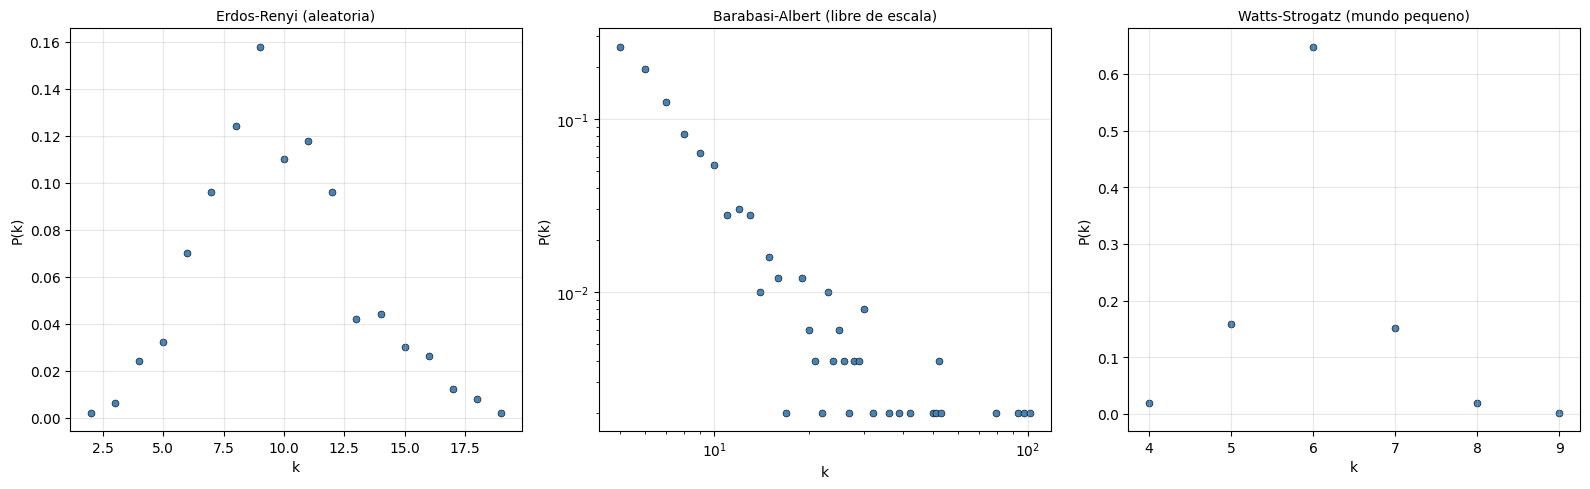

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nombre, G) in zip(axes, redes.items()):
    grados = np.array([d for _, d in G.degree()])
    grado_counts = Counter(grados)
    ks = np.array(sorted(grado_counts.keys()))
    pk = np.array([grado_counts[k] for k in ks]) / G.number_of_nodes()

    ax.scatter(ks, pk, s=25, color="steelblue", edgecolor="black", linewidth=0.4)
    ax.set_xlabel("k")
    ax.set_ylabel("P(k)")
    ax.set_title(nombre, fontsize=10)
    ax.grid(True, alpha=0.3)

    if "Barabasi" in nombre:
        ax.set_xscale("log")
        ax.set_yscale("log")

plt.tight_layout()
plt.savefig("degree_distributions.png", dpi=150)
plt.show()
